# Task 3 - Model Explainability with SHAP
**Adey Innovations Inc. | Fraud Detection**

This notebook covers:
1. Load best models (auto-detected from Task 2 results)
2. Built-in feature importance (baseline)
3. SHAP global summary plots
4. SHAP force plots — True Positive, False Positive, False Negative
5. Comparison: SHAP vs built-in importance
6. Top 5 fraud drivers & surprising findings
7. Business recommendations

# 0. Setup & Imports

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import shap
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')
shap.initjs()

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print('Libraries loaded. SHAP version:', shap.__version__)

c:\Users\3440\Downloads\fraud_detaction\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Libraries loaded. SHAP version: 0.52.0



## 1. Load Best Models (Auto-Detected from Task 2)

We read `models/test_set_results.csv` (produced by `modeling.ipynb`) and pick the model with the
highest **AUC-PR** for each dataset — keeping this notebook agnostic to which model actually won.

In [3]:
results_df = pd.read_csv('../models/test_set_results.csv')
display(results_df.sort_values(['dataset', 'AUC-PR'], ascending=[True, False]))

best_fraud_row = results_df[results_df['dataset'] == 'E-commerce'].sort_values('AUC-PR', ascending=False).iloc[0]
best_credit_row    = results_df[results_df['dataset'] == 'Credit Card'].sort_values('AUC-PR', ascending=False).iloc[0]

print(f"\nBest E-commerce model : {best_fraud_row['model']}  (AUC-PR={best_fraud_row['AUC-PR']:.4f})")
print(f"Best Credit Card model: {best_credit_row['model']}  (AUC-PR={best_credit_row['AUC-PR']:.4f})")

,model,dataset,AUC-PR,F1,ROC-AUC
0,Random Forest,Credit Card,0.021462,0.009063,0.549283
1,XGBoost,Credit Card,0.015033,0.015748,0.545280
2,Logistic Regression,Credit Card,0.013090,0.016158,0.688686
3,LightGBM,Credit Card,0.009036,0.016949,0.549602
4,Random Forest,E-commerce,0.619555,0.228589,0.766187
5,LightGBM,E-commerce,0.618693,0.267249,0.762790
6,XGBoost,E-commerce,0.582620,0.259307,0.764634
7,Logistic Regression,E-commerce,0.554554,0.211228,0.757461



Best E-commerce model : Random Forest  (AUC-PR=0.6196)
Best Credit Card model: Random Forest  (AUC-PR=0.0215)


In [5]:
name_to_file = {
    'Logistic Regression': 'logistic_regression',
    'Random Forest':       'random_forest',
    'XGBoost':              'xgboost',
    'LightGBM':             'lightgbm',
}

fraud_model_file = f"../models/{name_to_file[best_fraud_row['model']]}_fraud.pkl"
credit_model_file    = f"../models/{name_to_file[best_credit_row['model']]}_cc.pkl"

best_fraud_model = joblib.load(fraud_model_file)
best_credit_model    = joblib.load(credit_model_file)

print(f'Loaded: {fraud_model_file}')
print(f'Loaded: {credit_model_file}')

Loaded: ../models/random_forest_fraud.pkl
Loaded: ../models/random_forest_cc.pkl


### 1.1 Load Test Data

> Re-run the preprocessing cells from `modeling.ipynb` (or load saved processed test sets) so
> `X_fraud_test`, `y_fraud_test`, `X_cc_test`, `y_cc_test` are available here.

In [8]:
try:
    X_fraud_test = pd.read_csv('../data/processed/X_fraud_test.csv')
    y_fraud_test = pd.read_csv('../data/processed/y_fraud_test.csv').squeeze()
    X_credit_test    = pd.read_csv('../data/processed/X_credit_test.csv')
    y_credit_test    = pd.read_csv('../data/processed/y_credit_test.csv').squeeze()
    print('Loaded saved test sets from ../data/processed/')
except FileNotFoundError:
    print('Saved test sets not found.')
    print('>>> Re-run the preprocessing + train-test split cells from modeling.ipynb here,')
    print('    or export X_fraud_test/y_fraud_test/X_credit_test/y_credit_test to CSV from that notebook.')

print('\nX_fraud_test:', X_fraud_test.shape if 'X_fraud_test' in dir() else 'NOT LOADED')
print('X_credit_test   :', X_credit_test.shape if 'X_credit_test' in dir() else 'NOT LOADED')

Loaded saved test sets from ../data/processed/

X_fraud_test: (30223, 6)
X_credit_test   : (10000, 9)



## 2. Built-in Feature Importance (Baseline)

Before SHAP, we extract each model's native feature importance (`feature_importances_` for
tree-based models, or absolute coefficients for Logistic Regression) as a baseline comparison.

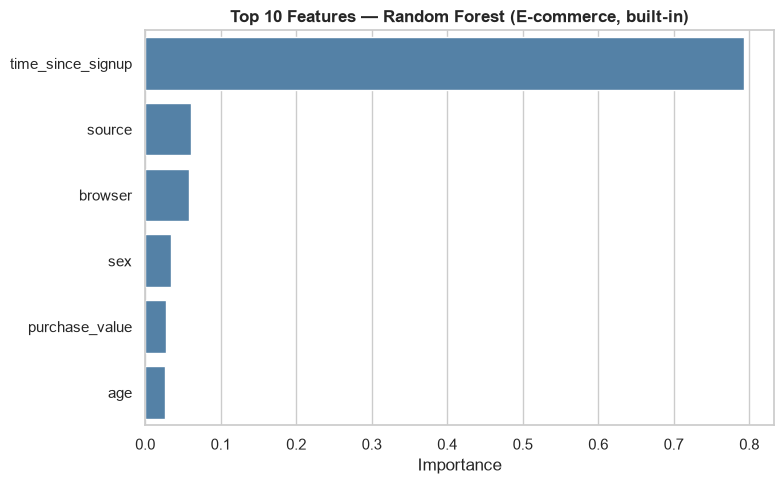

,feature,importance
5,time_since_signup,0.793131
1,source,0.060579
2,browser,0.058045
3,sex,0.034685
0,purchase_value,0.027923
4,age,0.025637


In [9]:
def get_builtin_importance(model, feature_names, top_n=10):
    """Extract built-in importance, handling both raw estimators and pipelines."""
    estimator = model
    if hasattr(model, 'named_steps'):
        estimator = model.named_steps.get('clf', model.named_steps[list(model.named_steps)[-1]])

    if hasattr(estimator, 'feature_importances_'):
        importance = estimator.feature_importances_
    elif hasattr(estimator, 'coef_'):
        importance = np.abs(estimator.coef_[0])
    else:
        raise ValueError('Model has no feature_importances_ or coef_ attribute')

    imp_df = pd.DataFrame({'feature': feature_names, 'importance': importance})
    imp_df = imp_df.sort_values('importance', ascending=False).head(top_n)
    return imp_df


def plot_importance(imp_df, title):
    plt.figure(figsize=(8, 5))
    sns.barplot(data=imp_df, y='feature', x='importance', color='steelblue')
    plt.title(title, fontweight='bold')
    plt.xlabel('Importance')
    plt.ylabel('')
    plt.tight_layout()
    plt.show()


fraud_builtin_imp = get_builtin_importance(best_fraud_model, X_fraud_test.columns.tolist())
plot_importance(fraud_builtin_imp, f'Top 10 Features — {best_fraud_row["model"]} (E-commerce, built-in)')
display(fraud_builtin_imp)

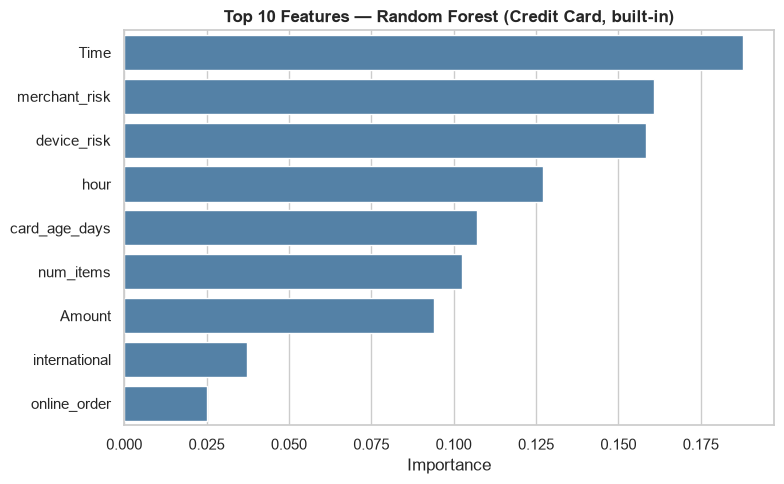

,feature,importance
0,Time,0.187836
2,merchant_risk,0.160749
3,device_risk,0.158469
8,hour,0.127159
5,card_age_days,0.107030
6,num_items,0.102456
1,Amount,0.093896
4,international,0.037404
7,online_order,0.025001


In [10]:
cc_builtin_imp = get_builtin_importance(best_credit_model, X_credit_test.columns.tolist())
plot_importance(cc_builtin_imp, f'Top 10 Features — {best_credit_row["model"]} (Credit Card, built-in)')
display(cc_builtin_imp)


## 3. SHAP Analysis — E-commerce Model

### 3.1 Compute SHAP Values

In [ ]:
import numpy as np
import pandas as pd
import shap

if hasattr(best_fraud_model, 'named_steps'):
    pure_model = best_fraud_model.named_steps['clf']
    preprocessor = best_fraud_model.named_steps['preprocessor']
    
    X_fraud_test_numeric = preprocessor.transform(X_fraud_test)
    
    if hasattr(X_fraud_test_numeric, "toarray"):
        X_fraud_test_numeric = X_fraud_test_numeric.toarray()
        
    if hasattr(preprocessor, 'get_feature_names_out'):
        feature_names = preprocessor.get_feature_names_out()
    else:
        feature_names = [f"feature_{i}" for i in range(X_fraud_test_numeric.shape[1])]
        
    X_fraud_test_processed = pd.DataFrame(X_fraud_test_numeric, columns=feature_names, index=X_fraud_test.index)
else:
    pure_model = best_fraud_model
    
    print("Pure model detected. Re-encoding categorical columns manually...")
    categorical_cols = X_fraud_test.select_dtypes(include=['object', 'category']).columns
    
    X_fraud_test_processed = pd.get_dummies(X_fraud_test, columns=categorical_cols, drop_first=True)
    
    if 'X_fraud_res' in locals() or 'X_fraud_res' in globals():
        X_fraud_test_processed = X_fraud_test_processed.reindex(columns=X_fraud_res.columns, fill_value=0)


# 3. SAMPLE AND RUN SHAP ON THE PURE NUMERICAL DATA
SAMPLE_SIZE = min(2000, len(X_fraud_test_processed))
sample_idx = X_fraud_test_processed.sample(SAMPLE_SIZE, random_state=RANDOM_STATE).index

X_fraud_sample = X_fraud_test_processed.loc[sample_idx]
y_fraud_sample = y_fraud_test.loc[sample_idx]

print(f'Computing SHAP values for {SAMPLE_SIZE} E-commerce samples...')

explainer_fraud = shap.TreeExplainer(pure_model) if hasattr(pure_model, 'feature_importances_') \
    else shap.Explainer(pure_model, X_fraud_sample)

shap_values_fraud = explainer_fraud.shap_values(X_fraud_sample) if hasattr(explainer_fraud, 'shap_values') \
    else explainer_fraud(X_fraud_sample).values

if isinstance(shap_values_fraud, list):
    shap_values_fraud = shap_values_fraud[1]

print('SHAP values computed. Shape:', np.array(shap_values_fraud).shape)

Pure model detected. Re-encoding categorical columns manually...
Computing SHAP values for 2000 E-commerce samples...
SHAP values computed. Shape: (2000, 10, 2)


## 3.2 SHAP Summary Plot

<Figure size 640x480 with 0 Axes>

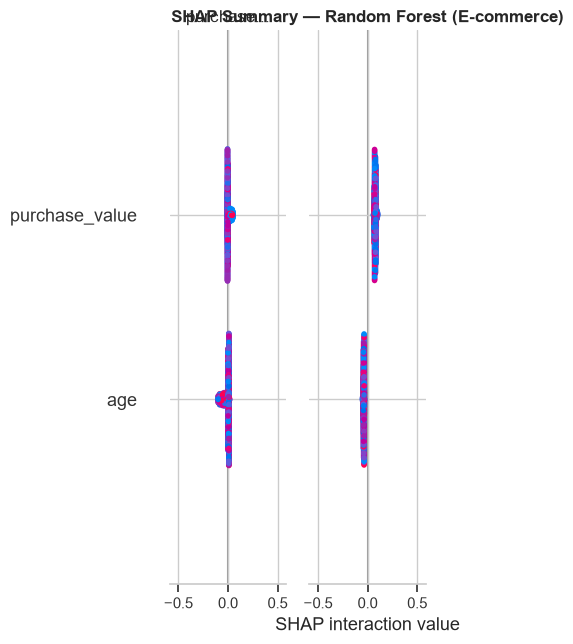

In [15]:
plt.figure()
shap.summary_plot(shap_values_fraud, X_fraud_sample, show=False)
plt.title(f'SHAP Summary — {best_fraud_row["model"]} (E-commerce)', fontweight='bold')
plt.tight_layout()
plt.show()

<Figure size 640x480 with 0 Axes>

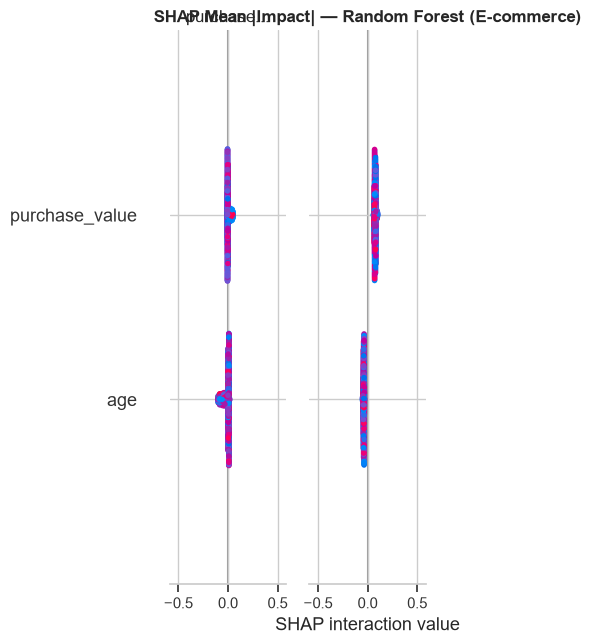

,feature,mean_abs_shap
5,browser_FireFox,9.528239e-15
4,source_SEO,4.980868e-16
1,age,4.113793e-16
2,time_since_signup,2.683036e-16
0,purchase_value,1.013367e-16
3,source_Direct,7.166923e-17
6,browser_IE,0.000000e+00
7,browser_Opera,0.000000e+00
8,browser_Safari,0.000000e+00
9,sex_M,0.000000e+00


In [17]:
plt.figure()
shap.summary_plot(shap_values_fraud, X_fraud_sample, plot_type='bar', show=False)
plt.title(f'SHAP Mean |Impact| — {best_fraud_row["model"]} (E-commerce)', fontweight='bold')
plt.tight_layout()
plt.show()

shap_arr = np.array(shap_values_fraud)

if shap_arr.ndim == 3:
    shap_arr = shap_arr.mean(axis=-1)

mean_abs_impact = np.abs(shap_arr).mean(axis=0)

shap_importance_fraud = pd.DataFrame({
    'feature': X_fraud_sample.columns,
    'mean_abs_shap': mean_abs_impact
}).sort_values('mean_abs_shap', ascending=False)

display(shap_importance_fraud.head(10))

### 3.3 SHAP Force Plots — Individual Predictions

We need three concrete cases:
- **True Positive** — model correctly caught fraud
- **False Positive** — legitimate transaction wrongly flagged
- **False Negative** — fraud the model missed